# Learning Fusion 4 — Hands-On: BEV Fusion (lift-splat + PointPillars → 3D boxes)

This notebook lets you **see the numbers and tensor shapes** behind **Section 4** of
`LEARNING_FUSION.md` / `LEARNING_FUSION.html` — the canonical automotive approach: fuse camera
and LiDAR in a **top-down BEV (bird's-eye-view)** grid and predict **3D boxes**
`(x, y, z, w, h, l, yaw)`.

It is **self-contained** — no uploads needed — and runs as-is in **Google Colab**
(`numpy`, `matplotlib`, `torch` all preinstalled). No `shapely` dependency: the rotated-IoU
cell implements a self-contained Sutherland–Hodgman polygon clip in numpy.

The code mirrors your repo (faithful interfaces, simplified internals so it runs in seconds on
a CPU):
- `Fusion3D._lift_splat`    ↔  `fusion/fusion/fusion_3d/model.py`     (camera → BEV)
- `PillarBEVEncoder`       ↔  `common/backbones/lidar_encoder.py`    (lidar → BEV)
- BEV geometry             ↔  `common/geometry/bev.py`
- 3D encode/decode/IoU/NMS ↔  `common/geometry/boxes3d.py`, `fusion/common_3d.py`
- 3D head / losses         ↔  `fusion/heads.py` (`CenterHead3D`), `train/losses_3d.py`

**Convention (KITTI cam frame):** x right, y down, z forward. **BEV grid:** dim0 (r) = z
(forward), dim1 (c) = x (right), centered on ego: `z = -range + (r+0.5)*res`, `x = -range + (c+0.5)*res`.

> Run top-to-bottom. Each branch: build it → run the real forward (shapes at every step) →
fuse → train a few steps so a 3D box appears → decode. Then rotated IoU/NMS is walked line-by-line.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch, torch.nn as nn, torch.nn.functional as F

torch.manual_seed(0); np.random.seed(0)

# ---- config: mirrors config/base.yaml + config/fusion_3d.yaml, shrunk for a fast CPU demo ----
cfg = dict(
    image_size=(384, 1280),       # [H, W]
    stride=16,                   # image feature stride for lift-splat -> 24x80 image grid
    num_classes=1, classes=["Car"],
    fusion_channels=32,           # image backbone out (base.yaml uses 256)
    CAM_BEV=32, LID_BEV=32, FUSED_BEV=64,   # repo uses 64/64/128; shrunk here
    head_hidden=64,              # heads.py uses 128
    bev=dict(range_m=32.0, res_m=0.4),      # fusion_3d.yaml: 160x160 grid (laptop-friendly)
    lift=dict(depth_bins=16, depth_max_m=40.0),
)
H, W = cfg["image_size"]; s = cfg["stride"]
Hf, Wf = H // s, W // s                       # image feature grid (for lift-splat)
RANGE, RES = cfg["bev"]["range_m"], cfg["bev"]["res_m"]
Hg, Wg = int(2*RANGE/RES), int(2*RANGE/RES)   # BEV grid = 160 x 160
K, DMAX = cfg["lift"]["depth_bins"], cfg["lift"]["depth_max_m"]
device = "cpu"
print(f"image {H}x{W}  ->  image feat grid {Hf}x{Wf} at stride {s}")
print(f"BEV grid {Hg}x{Wg}  (range +/-{RANGE} m, res {RES} m)  ->  cell size {RES}x{RES} m")
print(f"lift-splat: K={K} depth bins over 0..{DMAX} m  (bin width {DMAX/K:.2f} m)")
print(f"channels: CAM_BEV={cfg['CAM_BEV']}  LID_BEV={cfg['LID_BEV']}  FUSED_BEV={cfg['FUSED_BEV']}")


image 384x1280  ->  image feat grid 24x80 at stride 16
BEV grid 160x160  (range +/-32.0 m, res 0.4 m)  ->  cell size 0.4x0.4 m
lift-splat: K=16 depth bins over 0..40.0 m  (bin width 2.50 m)
channels: CAM_BEV=32  LID_BEV=32  FUSED_BEV=64


## Section 4 · Why BEV, and where does fusion happen here?

The 2D variants (Section 3) predict boxes in **image pixels**. For driving we want **metric 3D
boxes**: where is the car in the world, how big, which way is it pointing? The clean way is to put
both sensors into a common **top-down metric grid (BEV)** and detect there.

```
camera : image -> backbone -> [lift-splat] -> BEV_cam  (B, Cc, 160, 160)   # each pixel lifted to 3D, splatted down
lidar  : points -> [PointPillars]         -> BEV_lid (B, Cl, 160, 160)   # points -> pillars -> per-cell features
                          cat([BEV_cam, BEV_lid]) + 1x1 conv -> BEV_fused (B, Cf, 160, 160)
                                                              -> CenterHead3D -> 3D boxes (x,y,z,w,h,l,yaw)
```

A 3D box is `(x, y, z, w, h, l, yaw)`: center `(x,y,z)` in cam frame, extents
`(w=x, h=y-down, l=z-forward)`, and `yaw` = heading in the BEV `(x,z)` plane measured from +x CCW.

> **Honest scope** (from your repo docstring): the lift-splat here is the *simplified* variant
> (direct splat, no frustum pooling). Fine for learning the shapes; for publication 3D-AP reuse the
> KITTI devkit. At deploy, lift-splat/pillarize are CUDA preprocess — only the BEV-fuse + head is
> exported (matches production PointPillars-TRT pipelines).


In [2]:
# ---- Calib: mirrors common/sensors/calibration.py (numpy + torch_matrices hook) ----
class Calib:
    def __init__(self, P2, R0_rect, Tr_velo_to_cam):
        self.P2 = np.asarray(P2, float).reshape(3, 4)
        self.R0 = np.eye(4); self.R0[:3, :3] = np.asarray(R0_rect, float).reshape(3, 3)
        self.V2C = np.eye(4); self.V2C[:3, :] = np.asarray(Tr_velo_to_cam, float).reshape(3, 4)
        self.P  = np.eye(4); self.P[:3, :] = self.P2
    def velo_to_cam(self, pts):
        pts = np.atleast_2d(np.asarray(pts, float)); n = pts.shape[0]
        h = np.hstack([pts[:, :3], np.ones((n, 1))]); return (self.R0 @ self.V2C @ h.T).T[:, :3]
    def cam_to_image(self, c):
        c = np.atleast_2d(np.asarray(c, float)); n = c.shape[0]
        h = np.hstack([c, np.ones((n, 1))]); img = (self.P @ h.T).T[:, :3]; d = img[:, 2]
        return img[:, :2] / np.where(d == 0, 1e-9, d)[:, None], d
    def velo_to_image(self, pts):
        cam = self.velo_to_cam(pts); uv, d = self.cam_to_image(cam); return uv, d, cam
    def torch_matrices(self, device, dtype):
        return {"R0": torch.tensor(self.R0, device=device, dtype=dtype),
                "V2C": torch.tensor(self.V2C, device=device, dtype=dtype),
                "P":  torch.tensor(self.P,  device=device, dtype=dtype)}

def lidar_to_image(points, calib, H, W):
    uv, depth, _ = calib.velo_to_image(points[:, :3])
    valid = (depth > 0) & (uv[:, 0] >= 0) & (uv[:, 0] < W) & (uv[:, 1] >= 0) & (uv[:, 1] < H)
    return uv, depth, valid
def render_depth_image(points, calib, H, W, fill=0.0):
    uv, depth, valid = lidar_to_image(points, calib, H, W)
    img = np.full((H, W), fill, np.float32); uv, depth = uv[valid], depth[valid]
    if uv.shape[0] == 0: return img
    u, v = uv[:, 0].astype(int), uv[:, 1].astype(int); o = np.argsort(-depth)
    u, v, depth = u[o], v[o], depth[o]; img[v, u] = depth.astype(np.float32); return img

# self-consistent intrinsics for the 384x1280 demo image
fx = fy = 720.0; cx, cy = W/2., H/2.
P2 = np.array([[fx,0,cx,0],[0,fy,cy,0],[0,0,1,0]], float)
R_velo2cam = np.array([[0,-1,0],[0,0,-1],[1,0,0]], float)
t = np.array([0.0, -0.08, -0.27]); Tr = np.hstack([R_velo2cam, t.reshape(3, 1)]); R0 = np.eye(3)
calib = Calib(P2, R0, Tr)
print("Calib ready.  velo->cam chain: velo --V2C--> cam --R0--> cam(rect) --P2--> image")


Calib ready.  velo->cam chain: velo --V2C--> cam --R0--> cam(rect) --P2--> image


In [3]:
# ---- synthetic scene: a car (surface points) + ground, in velo frame ----
def make_car_pts(center, dims=(4.0, 2.0, 1.5), n_per_face=40, intensity=0.55):
    cx_, cy_, cz_ = center; lx, ly, lz = dims
    P = []
    for (a, ax) in [([-lx/2, lx/2], 0), ([-ly/2, ly/2], 1), ([-lz/2, lz/2], 2)]:
        for v in a:
            for _ in range(n_per_face):
                p = [cx_, cy_, cz_]; p[ax] += v
                for k in range(3):
                    if k != ax: p[k] += np.random.uniform(-dims[k]/2, dims[k]/2)
                P.append(p + [intensity])
    return np.array(P, float)

car_pts = make_car_pts([10.0, 2.0, 1.0])                       # 10 m ahead, 2 m left (velo)
ground = np.column_stack([np.random.uniform(5, 30, 120), np.random.uniform(-8, 8, 120),
                          np.full(120, 0.02), np.full(120, 0.1)])
points = np.vstack([car_pts, ground]); np.random.shuffle(points)
pts_t = torch.from_numpy(points)

# ---- GT 3D box in CAM frame. car center velo [10,2,1] -> cam [-2,-1.08,9.73] ----
cam_center = calib.velo_to_cam([[10, 2, 1]])[0]
# extents in cam frame: w = velo-y span (2), h = velo-z span (1.5), l = velo-x span (4)
# the car's length (l=4) lies along +z (forward); _bev_polygon puts l along z at yaw=0,
# so a forward-pointing car has yaw=0. yaw rotates the footprint CCW in the (x,z) plane.
# (repo docstring says 'from +x' but the code puts l along z at yaw=0 -- they disagree;
#  we trust the code here so the green footprint aligns with the LiDAR blob.)
gt_box3d = np.array([cam_center[0], cam_center[1], cam_center[2],   # x, y, z
                     2.0, 1.5, 4.0,                                   # w, h, l
                     0.0], float)                                    # yaw=0 -> forward (+z)
print("car center velo [10,2,1] -> cam", cam_center.round(3))
print("GT 3D box (x,y,z,w,h,l,yaw):", gt_box3d.round(3))
print("  -> BEV cell: r=(z+RANGE)/RES =", int((gt_box3d[2]+RANGE)/RES),
      " c=(x+RANGE)/RES =", int((gt_box3d[0]+RANGE)/RES))
gt_label = torch.tensor([0])


car center velo [10,2,1] -> cam [-2.   -1.08  9.73]
GT 3D box (x,y,z,w,h,l,yaw): [-2.   -1.08  9.73  2.    1.5   4.    0.  ]
  -> BEV cell: r=(z+RANGE)/RES = 104  c=(x+RANGE)/RES = 75


### BEV geometry, step by step

The BEV grid is a **metric top-down map** centered on the ego car. Cell `(r, c)` covers
`z = -range + (r+0.5)*res` (forward) and `x = -range + (c+0.5)*res` (right). With `range=32 m,
res=0.4 m` that's a **160×160** grid covering ±32 m around the car at 0.4 m resolution.

Below: where do a few cam-frame points land, including the GT car center?


In [4]:
def cam_to_bev_cell(x, z, range_m=RANGE, res=RES):
    r = (z + range_m) / res; c = (x + range_m) / res
    return r, c
print(f"ego (x=0,z=0)        -> cell (r={80.0:.1f}, c={80.0:.1f})   # grid center")
r, c = cam_to_bev_cell(gt_box3d[0], gt_box3d[2])
print(f"GT car (x={gt_box3d[0]:.1f}, z={gt_box3d[2]:.1f}) -> cell (r={r:.2f}, c={c:.2f})  -> ({int(r)},{int(c)})")
# a few sample points
for xm, zm in [(-5, 5), (0, 10), (5, 20), (-10, 30)]:
    rr, cc = cam_to_bev_cell(xm, zm)
    print(f"  point (x={xm:+d}, z={zm:2d})    -> cell (r={rr:.1f}, c={cc:.1f})" +
          ("  IN grid" if 0 <= rr < Hg and 0 <= cc < Wg else "  OUT"))
print(f"\ngrid covers x in [{-RANGE}, {RANGE}] m  and  z in [{-RANGE}, {RANGE}] m  (forward = +z)")


ego (x=0,z=0)        -> cell (r=80.0, c=80.0)   # grid center
GT car (x=-2.0, z=9.7) -> cell (r=104.33, c=75.00)  -> (104,75)
  point (x=-5, z= 5)    -> cell (r=92.5, c=67.5)  IN grid
  point (x=+0, z=10)    -> cell (r=105.0, c=80.0)  IN grid
  point (x=+5, z=20)    -> cell (r=130.0, c=92.5)  IN grid
  point (x=-10, z=30)    -> cell (r=155.0, c=55.0)  IN grid

grid covers x in [-32.0, 32.0] m  and  z in [-32.0, 32.0] m  (forward = +z)


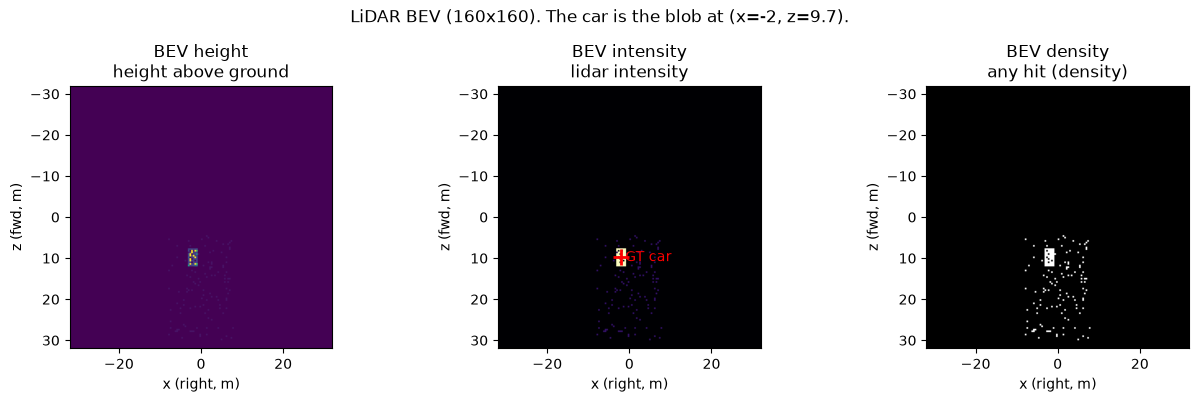

In [5]:
# ---- visualize the LiDAR BEV: [height, intensity, density] (mirror bev.points_to_bev_image) ----
def points_to_bev_image(points, range_m=RANGE, res=RES, max_h=3.0):
    img = np.zeros((Hg, Wg, 3), np.float32)
    pts_cam = calib.velo_to_cam(points)               # cam frame for BEV
    x, z, y = pts_cam[:, 0], pts_cam[:, 2], pts_cam[:, 1]
    inten = points[:, 3] if points.shape[1] >= 4 else np.zeros_like(x)
    r = ((z + range_m)/res).astype(int); c = ((x + range_m)/res).astype(int)
    m = (r >= 0) & (r < Hg) & (c >= 0) & (c < Wg)
    r, c, y, inten = r[m], c[m], y[m], inten[m]
    hgt = np.clip(-y / max(max_h, 1e-6), 0, 1)
    o = np.argsort(-hgt); r, c, hgt, inten = r[o], c[o], hgt[o], inten[o]
    img[r, c, 0] = hgt.astype(np.float32); img[r, c, 1] = inten.astype(np.float32); img[r, c, 2] = 1.0
    return img, pts_cam

bev_img, pts_cam = points_to_bev_image(points)
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for i, (n, cm, t) in enumerate(zip(["height", "intensity", "density"],
                                  ["viridis", "magma", "gray"],
                                  ["height above ground", "lidar intensity", "any hit (density)"])):
    ax[i].imshow(bev_img[..., i], cmap=cm, extent=[-RANGE, RANGE, RANGE, -RANGE])
    ax[i].set_title(f"BEV {n}\n{t}"); ax[i].set_xlabel("x (right, m)"); ax[i].set_ylabel("z (fwd, m)")
# mark GT car center
ax[1].plot(gt_box3d[0], gt_box3d[2], "r+", ms=12, mew=2)
ax[1].text(gt_box3d[0]+1, gt_box3d[2]+1, "GT car", color="red")
plt.suptitle("LiDAR BEV (160x160). The car is the blob at (x=-2, z=9.7).")
plt.tight_layout(); plt.show()


## 4.1 · Camera branch — simplified lift-splat-shoot

A 2D image has **no depth**. So the network must *learn* a per-pixel distribution over K candidate depths — the `softmax` over the `depth_head` logits. Lift-splat then **distributes each pixel's feature across those K candidate 3D points**, weighted by that distribution. This is the whole reason lift-splat exists: it is how you turn a depthless 2D feature map into a 3D (BEV) feature map.

Back-project every image pixel into 3D at each of K candidate depths, weighted by a learned
per-pixel depth distribution, and **splat** (sum) the pixel's feature into the BEV cell at its
`(x, z)`. This turns the 2D image feature map `(32, 24, 80)` into a BEV map `(32, 160, 160)`,
then a 1×1 conv shrinks it to `BEV_cam (CAM_BEV, 160, 160)`.

This is `Fusion3D._lift_splat` in `fusion/fusion_3d/model.py`. We run it with prints at every step.


In [6]:
# ---- TinyImageBackbone: same {stride: feat} interface as common/backbones/image_backbone.py ----
class TinyImageBackbone(nn.Module):
    def __init__(self, in_channels=3, out_channels=32):
        super().__init__(); self.strides = [16]
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, stride=2, padding=1), nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            nn.Conv2d(16, 24, 3, stride=2, padding=1), nn.BatchNorm2d(24), nn.ReLU(inplace=True),
            nn.Conv2d(24, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, out_channels, 3, stride=2, padding=1), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))
        self.out_channels = out_channels
    def forward(self, x): return {str(self.strides[0]): self.net(x)}

def lift_splat(feat, calib, K=K, depth_max=DMAX, range_m=RANGE, res=RES, verbose=True):
    """feat: (Cf,Hf,Wf) -> BEV_cam pre-reduce (Cf, Hg, Wg). Mirrors Fusion3D._lift_splat."""
    Cf, Hf, Wf = feat.shape; feat = feat.float()
    m = calib.torch_matrices(device, feat.dtype)
    fx_, fy_, cx_, cy_ = m["P"][0, 0], m["P"][1, 1], m["P"][0, 2], m["P"][1, 2]
    weights = torch.softmax(depth_head(feat.unsqueeze(0)).squeeze(0), dim=0)    # (K,Hf,Wf)
    us = (torch.arange(Wf)*s + s/2).view(1, Wf).expand(Hf, Wf).reshape(-1)
    vs = (torch.arange(Hf)*s + s/2).view(Hf, 1).expand(Hf, Wf).reshape(-1)
    bin_c = (torch.arange(K) + 0.5) * (depth_max / K)
    d = bin_c.view(K, 1).expand(K, Hf*Wf); u = us.view(1, -1).expand(K, Hf*Wf); v = vs.view(1, -1).expand(K, Hf*Wf)
    x = (u - cx_) * d / fx_; z = d                                   # cam-frame (y discarded in BEV)
    r = (z + range_m) / res; c = (x + range_m) / res
    valid = ((z > 0) & (r >= 0) & (r < Hg) & (c >= 0) & (c < Wg)).reshape(-1)
    if verbose:
        print(f"  image feat        : {tuple(feat.shape)}  (Cf, Hf={Hf}, Wf={Wf})")
        print(f"  depth dist softmax: {tuple(weights.shape)}  (K={K} bins per pixel)")
        print(f"  candidate 3D pts  : (K*Hf*Wf) = {K*Hf*Wf}  -> ({K}, {Hf*Wf})")
        print(f"  valid (in BEV)     : {int(valid.sum())} of {K*Hf*Wf}")
    w = weights.reshape(K, Hf*Wf).reshape(-1)[valid]
    p = torch.arange(Hf*Wf).view(1, -1).expand(K, Hf*Wf).reshape(-1)[valid]
    feat_flat = feat.view(Cf, Hf*Wf); src = feat_flat[:, p] * w
    lin = (r.reshape(-1)[valid].long() * Wg + c.reshape(-1)[valid].long())
    bev = torch.zeros(Cf, Hg*Wg, device=device, dtype=feat.dtype)
    bev.scatter_add_(1, lin.unsqueeze(0).expand(Cf, -1), src)
    bev = bev.view(Cf, Hg, Wg)
    if verbose: print(f"  splat -> BEV      : {tuple(bev.shape)}  (Cf, Hg, Wg)")
    return bev

img_backbone = TinyImageBackbone(3, cfg["fusion_channels"])
depth_head = nn.Conv2d(cfg["fusion_channels"], K, 1)
cam_reduce = nn.Conv2d(cfg["fusion_channels"], cfg["CAM_BEV"], 1)
img = np.zeros((H, W, 3), np.float32)
img[..., 0] = np.linspace(0.05, 0.25, W)[None, :]                          # faint horizon gradient
img += np.random.uniform(-0.02, 0.02, img.shape).astype(np.float32)
uc, vc = 492, 112                                                          # car center projects ~ here
img[max(0, vc-55):vc+55, max(0, uc-74):uc+74] += 0.35                       # brighter where the car is
img_t = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)
with torch.no_grad():
    feat = img_backbone(img_t)["16"][0]
    bev_cam_pre = lift_splat(feat, calib)
    bev_cam = cam_reduce(bev_cam_pre)
print(f"  cam_reduce 1x1    -> BEV_cam : {tuple(bev_cam.shape)}  (CAM_BEV={cfg['CAM_BEV']}, Hg, Wg)")


  image feat        : (32, 24, 80)  (Cf, Hf=24, Wf=80)
  depth dist softmax: (16, 24, 80)  (K=16 bins per pixel)
  candidate 3D pts  : (K*Hf*Wf) = 30720  -> (16, 1920)
  valid (in BEV)     : 24960 of 30720
  splat -> BEV      : (32, 160, 160)  (Cf, Hg, Wg)
  cam_reduce 1x1    -> BEV_cam : (32, 160, 160)  (CAM_BEV=32, Hg, Wg)


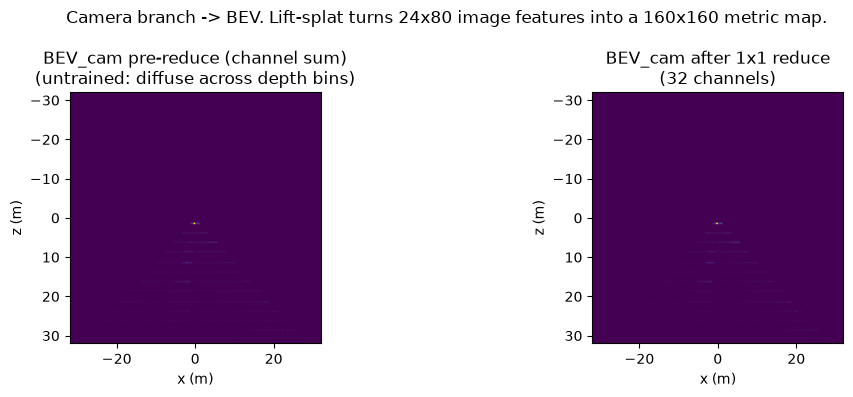

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(bev_cam_pre.abs().sum(0).numpy(), cmap="viridis", extent=[-RANGE, RANGE, RANGE, -RANGE])
ax[0].set_title("BEV_cam pre-reduce (channel sum)\n(untrained: diffuse across depth bins)")
ax[1].imshow(bev_cam.abs().sum(0).numpy(), cmap="viridis", extent=[-RANGE, RANGE, RANGE, -RANGE])
ax[1].set_title(f"BEV_cam after 1x1 reduce\n({cfg['CAM_BEV']} channels)")
for a in ax: a.set_xlabel("x (m)"); a.set_ylabel("z (m)")
plt.suptitle("Camera branch -> BEV. Lift-splat turns 24x80 image features into a 160x160 metric map.")
plt.tight_layout(); plt.show()


## 4.2 · LiDAR branch — simplified PointPillars

Assign each point to its BEV pillar (cell), build a per-point feature
`(x, y, z, intensity, dx, dz)` where `dx, dz` are the point's offset from its cell center, run a
per-point MLP, and **max-pool per cell**. Result: `BEV_lid (LID_BEV, 160, 160)`.

**Why max here but a *sum* for the camera branch?** A LiDAR point is a real, discrete measurement at one precise 3D location — you want the **most informative** point in each cell, so you take a max across points (`scatter_reduce_("amax")`). A camera pixel has *no* depth: it carries a *distribution* over K candidate depths, so a pixel contributes a little feature to many candidate 3D cells and you **accumulate** that weighted evidence (`scatter_add_`). Max for sharp point measurements; sum for diffuse probabilistic ones — that contrast is half the intuition for why BEV fusion works.

This is `PillarBEVEncoder` in `common/backbones/lidar_encoder.py`. Walked step by step below.


In [8]:
class PointMLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(inplace=True),
                                 nn.Linear(hidden, out_dim), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class PillarBEVEncoder(nn.Module):
    """points (velo) -> (B, LID_BEV, Hg, Wg). Mirrors common/backbones/lidar_encoder.py."""
    def __init__(self, out_channels=32, in_dim=6):
        super().__init__(); self.mlp = PointMLP(in_dim, out_channels); self.out_channels = out_channels
    def forward(self, points_list, calib_list, cfg_, device):
        bev = cfg_.get("bev", cfg_); range_m, res = float(bev["range_m"]), float(bev["res_m"])
        B = len(points_list); out = torch.zeros(B, self.out_channels, Hg, Wg, device=device)
        for b in range(B):
            pts = points_list[b].to(device).float()
            if pts.shape[0] == 0: continue
            m = calib_list[b].torch_matrices(device, pts.dtype); n = pts.shape[0]
            h = torch.cat([pts[:, :3], torch.ones((n, 1), device=device, dtype=pts.dtype)], dim=1)
            cam = (m["R0"] @ m["V2C"] @ h.t()).t()[:, :3]
            inten = pts[:, 3] if pts.shape[1] >= 4 else torch.zeros(n, device=device, dtype=pts.dtype)
            r = ((cam[:, 2] + range_m)/res).long(); c = ((cam[:, 0] + range_m)/res).long()
            valid = (r >= 0) & (r < Hg) & (c >= 0) & (c < Wg)
            if valid.sum() == 0: continue
            x, y, z, i = cam[valid, 0], cam[valid, 1], cam[valid, 2], inten[valid]
            rr, cc = r[valid].clamp(0, Hg-1), c[valid].clamp(0, Wg-1)
            cell_x = -range_m + (cc.float() + 0.5)*res; cell_z = -range_m + (rr.float() + 0.5)*res
            dx, dz = x - cell_x, z - cell_z                          # cell-relative
            feats = self.mlp(torch.stack([x, y, z, i, dx, dz], dim=-1)).float()
            lin = rr*Wg + cc
            grid = torch.zeros(self.out_channels, Hg*Wg, device=device)
            grid.scatter_reduce_(1, lin.unsqueeze(0).expand(self.out_channels, -1),
                                  feats.t(), reduce="amax", include_self=True)
            out[b] = grid.view(self.out_channels, Hg, Wg)
        return out

lid_enc = PillarBEVEncoder(out_channels=cfg["LID_BEV"])
with torch.no_grad():
    bev_lid = lid_enc([pts_t], [calib], cfg, device)
    # walk the intermediates once, in numpy for readable numbers
    cam_np = calib.velo_to_cam(points); r = ((cam_np[:, 2]+RANGE)/RES).astype(int); c = ((cam_np[:, 0]+RANGE)/RES).astype(int)
    valid = (r >= 0) & (r < Hg) & (c >= 0) & (c < Wg)
print(f"input points N            : {len(points)}")
print(f"-> cam frame               : {tuple(cam_np.shape)}  (x,y,z)")
print(f"-> BEV cell (r,c)          : valid in grid M = {int(valid.sum())}")
print(f"-> per-point feat (x,y,z,i,dx,dz): (M, 6) -> MLP -> feats (M, {cfg['LID_BEV']})")
print(f"-> max-pool per cell       : BEV_lid {tuple(bev_lid.shape)}  (B, LID_BEV, Hg, Wg)")
print(f"occupied BEV cells         : {int((bev_lid[0].abs().sum(0) > 0).sum())} / {Hg*Wg}")


input points N            : 360
-> cam frame               : (360, 3)  (x,y,z)
-> BEV cell (r,c)          : valid in grid M = 360
-> per-point feat (x,y,z,i,dx,dz): (M, 6) -> MLP -> feats (M, 32)
-> max-pool per cell       : BEV_lid (1, 32, 160, 160)  (B, LID_BEV, Hg, Wg)
occupied BEV cells         : 175 / 25600


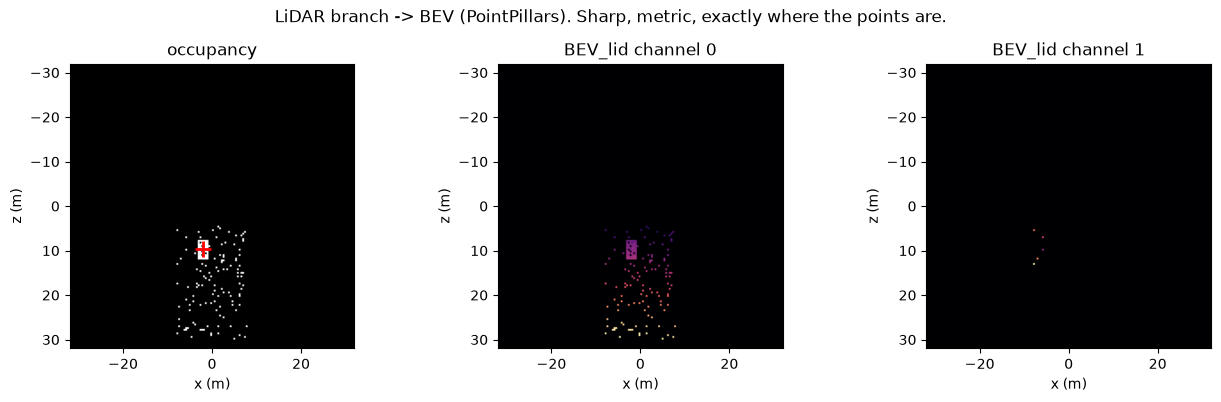

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
occ = (bev_lid[0].abs().sum(0) > 0).float().numpy()
ax[0].imshow(occ, cmap="gray", extent=[-RANGE, RANGE, RANGE, -RANGE]); ax[0].set_title("occupancy")
for i in range(2):
    ax[i+1].imshow(bev_lid[0, i].abs().numpy(), cmap="magma", extent=[-RANGE, RANGE, RANGE, -RANGE])
    ax[i+1].set_title(f"BEV_lid channel {i}")
for a in ax: a.set_xlabel("x (m)"); a.set_ylabel("z (m)")
ax[0].plot(gt_box3d[0], gt_box3d[2], "r+", ms=12, mew=2)
plt.suptitle("LiDAR branch -> BEV (PointPillars). Sharp, metric, exactly where the points are.")
plt.tight_layout(); plt.show()


## 4.3 · Fuse in BEV + 3D head

Both branches now live on the **same 160×160 metric grid**, so cell `(r,c)` in `BEV_cam` and
`BEV_lid` describes the *same patch of the world*. Concatenate channel-wise and squeeze with a
1×1 conv, then a `CenterHead3D` predicts five maps:
`heat (1,160,160)`, `off (2,160,160)` (dz, dx), `height (1,160,160)` (y), `size (3,160,160)`
(w, h, l), `yaw (2,160,160)` (sin, cos).


In [10]:
# ---- CenterHead3D: faithful copy of fusion/heads.py ----
class CenterHead3D(nn.Module):
    def __init__(self, in_channels, num_classes=1, hidden=64):
        super().__init__()
        self.head = nn.Sequential(nn.Conv2d(in_channels, hidden, 3, padding=1), nn.ReLU(inplace=True),
                                  nn.Conv2d(hidden, hidden, 3, padding=1), nn.ReLU(inplace=True))
        self.heat = nn.Conv2d(hidden, num_classes, 1); self.off = nn.Conv2d(hidden, 2, 1)
        self.height = nn.Conv2d(hidden, 1, 1); self.size = nn.Conv2d(hidden, 3, 1); self.yaw = nn.Conv2d(hidden, 2, 1)
        self.heat.bias.data.fill_(-2.19)
    def forward(self, feat):
        h = self.head(feat)
        return {"heat": self.heat(h), "off": self.off(h), "height": self.height(h),
                "size": self.size(h), "yaw": self.yaw(h)}

fuse_conv = nn.Conv2d(cfg["CAM_BEV"] + cfg["LID_BEV"], cfg["FUSED_BEV"], 1)
head3d = CenterHead3D(cfg["FUSED_BEV"], cfg["num_classes"], cfg["head_hidden"])

with torch.no_grad():
    bev_cam_b = bev_cam.unsqueeze(0); bev_lid_b = bev_lid.to(bev_cam.dtype)
    cat = torch.cat([bev_cam_b, bev_lid_b], dim=1)
    fused = fuse_conv(cat)
    pred = head3d(fused)
print("BEV_cam  :", tuple(bev_cam_b.shape))
print("BEV_lid  :", tuple(bev_lid_b.shape))
print("cat dim=1:", tuple(cat.shape), "  <- same 160x160; channels stacked")
print("1x1 conv -> BEV_fused:", tuple(fused.shape))
print("head outputs:")
for k, v in pred.items(): print(f"   {k:7s}: {tuple(v.shape)}")


BEV_cam  : (1, 32, 160, 160)
BEV_lid  : (1, 32, 160, 160)
cat dim=1: (1, 64, 160, 160)   <- same 160x160; channels stacked
1x1 conv -> BEV_fused: (1, 64, 160, 160)
head outputs:
   heat   : (1, 1, 160, 160)
   off    : (1, 2, 160, 160)
   height : (1, 1, 160, 160)
   size   : (1, 3, 160, 160)
   yaw    : (1, 2, 160, 160)


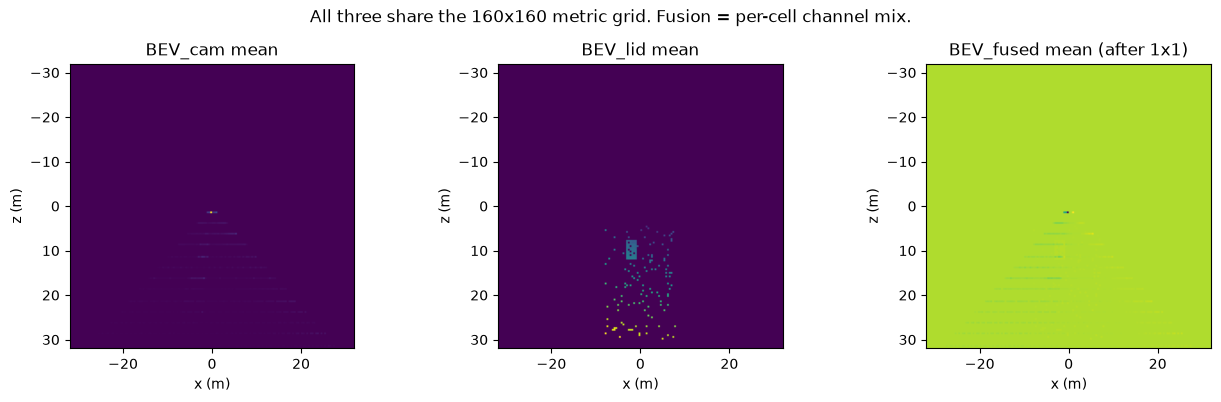

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for a, im, t in zip(ax,
                    [bev_cam_b[0].abs().mean(0).numpy(), bev_lid_b[0].abs().mean(0).numpy(), fused[0].mean(0).numpy()],
                    ["BEV_cam mean", "BEV_lid mean", "BEV_fused mean (after 1x1)"]):
    a.imshow(im, cmap="viridis", extent=[-RANGE, RANGE, RANGE, -RANGE]); a.set_title(t)
    a.set_xlabel("x (m)"); a.set_ylabel("z (m)")
plt.suptitle("All three share the 160x160 metric grid. Fusion = per-cell channel mix.")
plt.tight_layout(); plt.show()


## 4.4 · 3D box encode / decode

`encode_boxes3d` (cam-frame box → target maps): a Gaussian peak on the heatmap at cell
`(r, c)` from `(z, x)`; sub-cell offset `(dz, dx)`; `height = y`; `size = (w, h, l)`;
`yaw = (sin, cos)`. `decode_boxes3d` is the inverse: top-k the heatmap, gather the regressed
fields, reconstruct `(x, y, z, w, h, l, yaw)` with `x = (c+dx)*res - range`,
`z = (r+dz)*res - range`, `angle = atan2(sin, cos)`.

Let's encode the GT box and decode it back — a perfect round-trip shows the convention is right.

> **Why the decoded score is ~0.73, not 1.0.** The target heatmap stores raw Gaussian values (peak = 1.0), but `decode_boxes3d` applies `sigmoid` to the (logit) heatmap first — and `sigmoid(1.0) ≈ 0.73`. The box *geometry* round-trips exactly; only the score is squashed through sigmoid. That is why we decode with `thresh=0.5` here rather than 0.9.


In [12]:
# ---- encode/decode 3D: faithful copies of common/geometry/boxes3d.py ----
def gaussian_radius(h, w, min_overlap=0.7):
    b1 = h+w; a2=4; b2=2*(h+w)+1; c2=4*min_overlap
    dc = b1**2 - 4*a2*(c2+w*h); dr = b2**2 - 16*c2*w*h
    rc = (b1+np.sqrt(dc))/(2*a2) if dc > 0 else 0.0
    rr = (b2+np.sqrt(dr))/(2*a2) if dr > 0 else 0.0
    return max(0, int(min(rc, rr)))
def _draw_gaussian(heatmap, center, radius):
    diameter = 2*radius+1; sigma = diameter/6.0
    g = torch.tensor(np.exp(-((np.arange(diameter)-radius)**2)/(2*sigma**2)), dtype=heatmap.dtype)
    g2d = torch.outer(g, g); cy, cx = int(center[0]), int(center[1]); r = radius
    y0, y1 = max(0, cy-r), min(heatmap.shape[-2], cy+r+1); x0, x1 = max(0, cx-r), min(heatmap.shape[-1], cx+r+1)
    if y1>y0 and x1>x0:
        heatmap[..., y0:y1, x0:x1] = torch.maximum(heatmap[..., y0:y1, x0:x1],
            g2d[y0-(cy-r):y0-(cy-r)+(y1-y0), x0-(cx-r):x0-(cx-r)+(x1-x0)])
def encode_boxes3d(boxes, labels):
    heat = torch.zeros((1, Hg, Wg)); off = torch.zeros((2, Hg, Wg)); height = torch.zeros((1, Hg, Wg))
    size = torch.zeros((3, Hg, Wg)); yawc = torch.zeros((2, Hg, Wg))
    x, y, z, w, h, l, yaw = [boxes[:, i] for i in range(7)]
    r = ((z+RANGE)/RES).long().clamp(0, Hg-1); c = ((x+RANGE)/RES).long().clamp(0, Wg-1)
    for i in range(boxes.shape[0]):
        _draw_gaussian(heat[labels[i]], (r[i].item(), c[i].item()), gaussian_radius(max(h[i].item(),1), max(l[i].item(),1)))
    off[0, r, c] = (z+RANGE)/RES - r.float(); off[1, r, c] = (x+RANGE)/RES - c.float()
    height[0, r, c] = y; size[0, r, c] = w; size[1, r, c] = h; size[2, r, c] = l
    yawc[0, r, c] = torch.sin(yaw); yawc[1, r, c] = torch.cos(yaw)
    return {"heat": heat, "off": off, "height": height, "size": size, "yaw": yawc}
def _topk(heat, k=40):
    B, C, Hh, Ww = heat.shape; heat = heat.view(B, C, -1); scores, idx = heat.topk(k, dim=-1)
    scores, idx = scores.view(B, -1), idx.view(B, -1); cls = (idx//(Hh*Ww)).long(); cell = idx % (Hh*Ww)
    return scores, cls, (cell//Ww).long(), (cell%Ww).long()
def decode_boxes3d(pred, k=40, thresh=0.1):
    heat = pred["heat"].sigmoid(); B, C, Hgh, Wgh = heat.shape
    scores, labels, ys, xs = _topk(heat, k)
    def gather(t):
        t = t.permute(0, 2, 3, 1).contiguous().view(B, -1, t.shape[1]); idx = ys*Wgh + xs
        return torch.gather(t, 1, idx.unsqueeze(-1).expand(-1, -1, t.shape[-1]))
    off = gather(pred["off"]); height = gather(pred["height"]); size = gather(pred["size"]); yaw = gather(pred["yaw"])
    z = (ys.float()+off[..., 0])*RES - RANGE; x = (xs.float()+off[..., 1])*RES - RANGE; y = height[..., 0]
    w, h, l = size[..., 0], size[..., 1], size[..., 2]; angle = torch.atan2(yaw[..., 0], yaw[..., 1])
    out = []
    for b in range(B):
        m = scores[b] > thresh; s = scores[b][m]
        box = torch.stack([x[b][m], y[b][m], z[b][m], w[b][m], h[b][m], l[b][m], angle[b][m]], dim=-1)
        out.append({"boxes": box, "scores": s, "labels": labels[b][m]})
    return out

tgt = {k: v.unsqueeze(0) for k, v in encode_boxes3d(torch.from_numpy(gt_box3d[None]).float(), gt_label).items()}
print("encoded GT target:")
print(f"  heat peak cell (r,c) = ({int(np.argmax(tgt['heat'][0,0].numpy())//Wg)}, {int(np.argmax(tgt['heat'][0,0].numpy())%Wg)})")
print(f"  height (y)   = {tgt['height'][0,0].max().item():.3f}")
print(f"  size (w,h,l)  = {[tgt['size'][0,i].max().item() for i in range(3)]}")
print(f"  yaw (sin,cos) = ({tgt['yaw'][0,0].max().item():.3f}, {tgt['yaw'][0,1].max().item():.3f})")
# decode the *target* back (perfect round-trip check)
dec = decode_boxes3d(tgt, k=5, thresh=0.5)[0]
print("\nround-trip decode of the encoded GT:", dec["boxes"][0].numpy().round(3))
print("original GT                         :", gt_box3d.round(3))


encoded GT target:
  heat peak cell (r,c) = (104, 75)
  height (y)   = 0.000
  size (w,h,l)  = [2.0, 1.5, 4.0]
  yaw (sin,cos) = (0.000, 1.000)

round-trip decode of the encoded GT: [-2.   -1.08  9.73  2.    1.5   4.    0.  ]
original GT                         : [-2.   -1.08  9.73  2.    1.5   4.    0.  ]


In [13]:
# ---- losses_3d: faithful copy of train/losses_3d.py (returns a DICT, key 'loss') ----
def focal_loss(pred, target, alpha=2.0, beta=4.0, eps=1e-6):
    pred = pred.sigmoid().clamp(eps, 1-eps); pos = target.eq(1).float(); neg = target.lt(1).float()
    num_pos = pos.sum().clamp(min=1)
    return (-((1-pred)**alpha)*torch.log(pred)*pos - ((1-target)**beta)*(pred**alpha)*torch.log(1-pred)*neg).sum()/num_pos
def l1_loss(pred, target, mask):
    return F.l1_loss(pred*mask, target*mask, reduction="sum")/mask.sum().clamp(min=1)
def compute_3d_loss(pred, target):
    mask = (target["heat"].max(dim=1, keepdim=True)[0] > 0.99).float()
    return {"loss": focal_loss(pred["heat"], target["heat"]) + l1_loss(pred["off"], target["off"], mask)
            + l1_loss(pred["height"], target["height"], mask) + 0.1*l1_loss(pred["size"], target["size"], mask)
            + 0.5*l1_loss(pred["yaw"], target["yaw"], mask)}

opt = torch.optim.Adam(list(img_backbone.parameters()) + list(depth_head.parameters()) +
                       list(cam_reduce.parameters()) + list(lid_enc.parameters()) +
                       list(fuse_conv.parameters()) + list(head3d.parameters()), lr=3e-3)
print("step |  loss")
for step in range(1, 121):
    opt.zero_grad()
    feat = img_backbone(img_t)["16"][0]
    bev_cam_ = cam_reduce(lift_splat(feat, calib, verbose=False))
    bev_lid_ = lid_enc([pts_t], [calib], cfg, device).to(bev_cam_.dtype)
    p = head3d(fuse_conv(torch.cat([bev_cam_.unsqueeze(0), bev_lid_], dim=1)))
    loss = compute_3d_loss(p, tgt)["loss"]; loss.backward(); opt.step()
    if step % 30 == 0 or step == 1: print(f"{step:4d} | {loss.item():.4f}")

with torch.no_grad():
    feat = img_backbone(img_t)["16"][0]
    p = head3d(fuse_conv(torch.cat([cam_reduce(lift_splat(feat, calib, verbose=False)).unsqueeze(0),
                                    lid_enc([pts_t], [calib], cfg, device)], dim=1)))
    dec = decode_boxes3d(p, k=10, thresh=0.2)[0]
print("\nGT 3D box :", gt_box3d.round(3))
if dec["boxes"].shape[0]:
    print("decoded    :", dec["boxes"][0].numpy().round(3), " score=%.3f" % dec["scores"][0])
else:
    print("decoded    : (none above threshold)")


step |  loss
   1 | 30.0445


  30 | 1.0486


  60 | 0.3655


  90 | 0.1350


 120 | 0.3800

GT 3D box : [-2.   -1.08  9.73  2.    1.5   4.    0.  ]
decoded    : [-1.989e+00 -9.140e-01  9.727e+00  1.805e+00  1.426e+00  3.672e+00
 -8.000e-03]  score=0.785


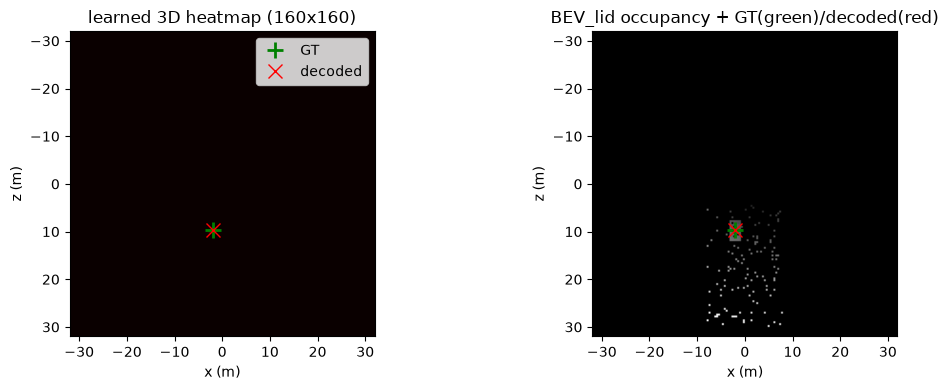

In [14]:
with torch.no_grad():
    hm = p["heat"][0, 0].sigmoid().numpy()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(hm, cmap="hot", extent=[-RANGE, RANGE, RANGE, -RANGE]); ax[0].set_title("learned 3D heatmap (160x160)")
ax[0].plot(gt_box3d[0], gt_box3d[2], "g+", ms=12, mew=2, label="GT")
if dec["boxes"].shape[0]:
    ax[0].plot(dec["boxes"][0, 0].item(), dec["boxes"][0, 2].item(), "rx", ms=10, label="decoded")
ax[0].legend(loc="upper right")
# footprints are drawn in the rotated-IoU cell below; here we just mark centers
ax[1].imshow(bev_lid[0].abs().sum(0).numpy(), cmap="gray", extent=[-RANGE, RANGE, RANGE, -RANGE])
ax[1].plot(gt_box3d[0], gt_box3d[2], "g+", ms=12, mew=2)
if dec["boxes"].shape[0]:
    ax[1].plot(dec["boxes"][0, 0].item(), dec["boxes"][0, 2].item(), "rx", ms=10)
ax[1].set_title("BEV_lid occupancy + GT(green)/decoded(red)")
for a in ax: a.set_xlabel("x (m)"); a.set_ylabel("z (m)")
plt.tight_layout(); plt.show()


## 4.5 · Rotated BEV IoU + NMS

Cars are **not** axis-aligned, so 2D IoU on upright rectangles is wrong. The repo computes
rotated IoU with `shapely`; here we implement it **self-contained** in numpy via Sutherland–Hodgman
convex-polygon clipping, so it runs anywhere. `_bev_polygon` builds the 4-corner footprint in the
`(x, z)` plane exactly as `boxes3d._bev_polygon` does.


In [15]:
# ---- rotated BEV IoU/NMS: numpy, Sutherland-Hodgman clip (no shapely needed) ----
def _bev_polygon(x, z, w, l, yaw):
    """4-corner footprint in (x,z). Mirrors common/geometry/boxes3d._bev_polygon."""
    dx = np.array([w/2, -w/2, -w/2, w/2]); dz = np.array([l/2, l/2, -l/2, -l/2])
    cos, sin = np.cos(yaw), np.sin(yaw)
    rx = x + dx*cos - dz*sin; rz = z + dx*sin + dz*cos
    return list(zip(rx, rz))
def _area_signed(poly):
    s = 0.0; n = len(poly)
    for i in range(n):
        x1, y1 = poly[i]; x2, y2 = poly[(i+1) % n]; s += x1*y2 - x2*y1
    return s/2.0
def _seg_intersect(S, E, A, B):
    x1, y1 = S; x2, y2 = E; x3, y3 = A; x4, y4 = B
    denom = (x1-x2)*(y3-y4) - (y1-y2)*(x3-x4)
    t = ((x1-x3)*(y3-y4) - (y1-y3)*(x3-x4)) / denom
    return (x1 + t*(x2-x1), y1 + t*(y2-y1))
def _clip(subject, clip):
    out = list(subject); sign = 1.0 if _area_signed(clip) > 0 else -1.0; n = len(clip)
    for i in range(n):
        if not out: break
        A, B = clip[i], clip[(i+1) % n]
        def inside(p): return sign*((B[0]-A[0])*(p[1]-A[1]) - (B[1]-A[1])*(p[0]-A[0])) >= 0
        inp, nxt = out, []
        S = inp[-1]
        for E in inp:
            if inside(E):
                if not inside(S): nxt.append(_seg_intersect(S, E, A, B))
                nxt.append(E)
            elif inside(S):
                nxt.append(_seg_intersect(S, E, A, B))
            S = E
        out = nxt
    return out
def poly_area(poly):
    if len(poly) < 3: return 0.0
    return abs(_area_signed(poly))
def rotated_bev_iou(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    out = np.zeros((a.shape[0], b.shape[0]))
    if a.shape[0] == 0 or b.shape[0] == 0: return out
    pa = [_bev_polygon(*ab[[0, 2, 3, 5, 6]]) for ab in a]; pb = [_bev_polygon(*bb[[0, 2, 3, 5, 6]]) for bb in b]
    for i, ai in enumerate(pa):
        for j, bj in enumerate(pb):
            inter = poly_area(_clip(ai, bj)); union = poly_area(ai) + poly_area(bj) - inter
            out[i, j] = inter/union if union > 1e-9 else 0.0
    return out
def rotated_nms3d(boxes, scores, iou_thresh=0.1):
    boxes = np.asarray(boxes, float); scores = np.asarray(scores, float)
    if boxes.shape[0] == 0: return np.array([], int)
    order = scores.argsort()[::-1]; keep = []
    while order.size > 0:
        i = order[0]; keep.append(i)
        if order.size == 1: break
        ovs = rotated_bev_iou(boxes[i:i+1], boxes[order[1:]])[0]
        order = order[1:][ovs < iou_thresh]
    return np.array(keep, int)
print("rotated IoU/NMS ready (Sutherland-Hodgman, numpy-only).")


rotated IoU/NMS ready (Sutherland-Hodgman, numpy-only).


In [16]:
# ---- rotated IoU walkthrough: show rotation matters ----
# A: w=4, l=2, yaw=0  -> axis-aligned footprint x in [-2,2], z in [-1,1]
# B: same w,l, yaw=pi/2 -> perpendicular footprint x in [-1,1], z in [-2,2]
A = np.array([[0, 0, 0, 4, 1, 2, 0.0]], float)
B = np.array([[0, 0, 0, 4, 1, 2, np.pi/2]], float)
print("Box A footprint (yaw=0)   :", np.round(_bev_polygon(0,0,4,2,0.0), 2).tolist())
print("Box B footprint (yaw=pi/2):", np.round(_bev_polygon(0,0,4,2,np.pi/2), 2).tolist())
iou = rotated_bev_iou(A, B)[0, 0]
print(f"\nrotated IoU(A, B) = {iou:.4f}   (correct: A is 4x2 horizontal, B is 2x4 vertical, inter=4, union=12)")
# naive axis-aligned (ignoring yaw, both 4x2 same center) would be 1.0
inter = poly_area(_clip(_bev_polygon(0,0,4,2,0.0), _bev_polygon(0,0,4,2,0.0)))
naive = inter/(8+8-inter)
print(f"naive axis-aligned (ignore yaw) would give {naive:.4f}  <- WRONG")
print("\nso: rotated IoU is essential. Cars at 90 deg to each other barely overlap in BEV.")


Box A footprint (yaw=0)   : [[2.0, 1.0], [-2.0, 1.0], [-2.0, -1.0], [2.0, -1.0]]
Box B footprint (yaw=pi/2): [[-1.0, 2.0], [-1.0, -2.0], [1.0, -2.0], [1.0, 2.0]]

rotated IoU(A, B) = 0.3333   (correct: A is 4x2 horizontal, B is 2x4 vertical, inter=4, union=12)
naive axis-aligned (ignore yaw) would give 1.0000  <- WRONG

so: rotated IoU is essential. Cars at 90 deg to each other barely overlap in BEV.


In [17]:
# ---- rotated NMS demo: overlapping 3D predictions ----
boxes = np.array([
    [0, 0, 0, 4, 1, 2, 0.0],        # base, score 0.9
    [0.5, 0, 0, 4, 1, 2, 0.10],     # ~same, score 0.7  -> should be suppressed
    [10, 0, 0, 4, 1, 2, 0.0],       # far away, score 0.6 -> kept
], float)
scores = np.array([0.9, 0.7, 0.6])
iou_mat = rotated_bev_iou(boxes, boxes)
print("pairwise IoU matrix:\n", np.round(iou_mat, 3))
keep = rotated_nms3d(boxes, scores, iou_thresh=0.1)
print(f"\nNMS (thresh=0.1) keeps indices {keep.tolist()}  -> scores {scores[keep].tolist()}")
print("(box 1 overlaps box 0 at IoU", round(float(iou_mat[0,1]),3), "-> suppressed; box 2 is separate -> kept)")


pairwise IoU matrix:
 [[1.    0.721 0.   ]
 [0.721 1.    0.   ]
 [0.    0.    1.   ]]

NMS (thresh=0.1) keeps indices [0, 2]  -> scores [0.9, 0.6]
(box 1 overlaps box 0 at IoU 0.721 -> suppressed; box 2 is separate -> kept)


## 4.6 · Blind modes / robustness

`Fusion3D` carries the same deploy-time switches: `cam_blind` and `lidar_blind`.
In the **repo**, `cam_blind` zeros the input *image* before the backbone (note: BatchNorm bias
means `BEV_cam` is then *not* exactly zero), and `lidar_blind` zeros `BEV_lid`. Below we go one
step cleaner and zero `BEV_cam` directly, so the camera branch is truly silent — the same idea,
just a cleaner ablation. Either way, concat + 1×1 conv + head keep working: the fused grid
loses one source but the surviving branch still carries the car.


In [18]:
with torch.no_grad():
    bev_cam_ok = cam_reduce(lift_splat(img_backbone(img_t)["16"][0], calib, verbose=False))
    bev_lid_ok = lid_enc([pts_t], [calib], cfg, device).to(bev_cam_ok.dtype)
    fused_ok   = fuse_conv(torch.cat([bev_cam_ok.unsqueeze(0), bev_lid_ok], dim=1))
    fused_camblind = fuse_conv(torch.cat([torch.zeros_like(bev_cam_ok).unsqueeze(0), bev_lid_ok], dim=1))
    fused_lidblind = fuse_conv(torch.cat([bev_cam_ok.unsqueeze(0), torch.zeros_like(bev_lid_ok)], dim=1))
print("normal      BEV_fused:", tuple(fused_ok.shape),     " mean=%.4f" % fused_ok.mean())
print("cam_blind   BEV_fused:", tuple(fused_camblind.shape), " mean=%.4f" % fused_camblind.mean())
print("lidar_blind BEV_fused:", tuple(fused_lidblind.shape), " mean=%.4f" % fused_lidblind.mean())
print("-> shapes never change; the surviving branch still produces a heatmap peak.")
# decode under lidar_blind (camera-only BEV is diffuse, but the head may still peak)
with torch.no_grad():
    p_bl = head3d(fused_lidblind)
    dec_bl = decode_boxes3d(p_bl, k=10, thresh=0.15)[0]
print("lidar_blind decoded boxes:", dec_bl["boxes"].shape[0], "(vs normal", dec["boxes"].shape[0], "above 0.15)")


normal      BEV_fused: (1, 64, 160, 160)  mean=0.0175
cam_blind   BEV_fused: (1, 64, 160, 160)  mean=0.0048
lidar_blind BEV_fused: (1, 64, 160, 160)  mean=0.0172
-> shapes never change; the surviving branch still produces a heatmap peak.
lidar_blind decoded boxes: 0 (vs normal 1 above 0.15)


## 4.7 · How it all fits together

| | 2D variants (Sec 3) | **3D / BEV (Sec 4)** |
|---|---|---|
| **output** | pixel boxes `(x1,y1,x2,y2)` | metric 3D boxes `(x,y,z,w,h,l,yaw)` |
| **fusion space** | image grid (24×80 px) | BEV metric grid (160×160, 0.4 m) |
| **cam branch** | backbone only | backbone → **lift-splat** → BEV_cam |
| **lidar branch** | image-grid encoder / 3ch render | **PointPillars** → BEV_lid |
| **head** | `heat/off/size` | `heat/off/height/size/yaw` |
| **IoU/NMS** | axis-aligned 2D | **rotated BEV** (polygon) |
| **export** | one engine | only BEV-fuse + head; lift/pillar are CUDA preprocess |

The 3D variant is the heaviest to build but the only one that gives you **where in the world,
how big, and which way it points** — which is what a planner needs.


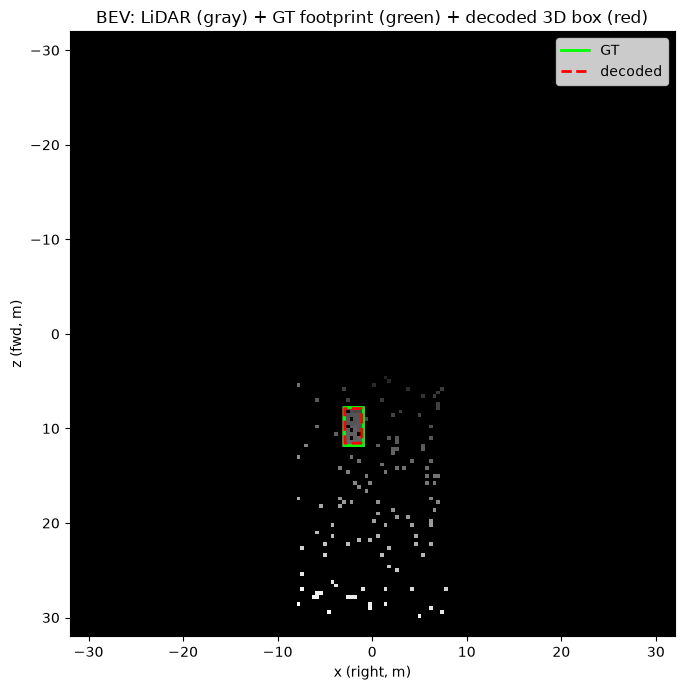

In [19]:
# ---- final picture: LiDAR BEV + GT footprint + decoded footprint ----
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(bev_lid[0].abs().sum(0).numpy(), cmap="gray", extent=[-RANGE, RANGE, RANGE, -RANGE])
def plot_footprint(box, **kw):
    poly = _bev_polygon(box[0], box[2], box[3], box[5], box[6])
    ax.plot([p[0] for p in poly]+[poly[0][0]], [p[1] for p in poly]+[poly[0][1]], **kw)
plot_footprint(gt_box3d, color="lime", lw=2, label="GT")
if dec["boxes"].shape[0]:
    plot_footprint(dec["boxes"][0].numpy(), color="red", lw=2, ls="--", label="decoded")
ax.set_xlim(-RANGE, RANGE); ax.set_ylim(RANGE, -RANGE); ax.set_xlabel("x (right, m)"); ax.set_ylabel("z (fwd, m)")
ax.set_title("BEV: LiDAR (gray) + GT footprint (green) + decoded 3D box (red)")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()


## 4.8 · 2D vs 3D — side by side

The 2D variants (Section 3) and this 3D/BEV variant answer **different questions for the same
car**. Below we run a tiny 2D pipeline on the *same* synthetic frame — image features + LiDAR
rendered onto the **image grid** → `CenterHead2D` → a pixel box `(x1,y1,x2,y2)` — and contrast
it with the 3D/BEV pipeline you just built. Four comparisons, each a picture:

1. **Image space** — a 3D box *projected back* to pixels looks just like a 2D box: 3D contains 2D.
2. **BEV space** — the 2D box only fixes a *bearing* (a wedge from the camera); the 3D box picks an
   exact spot along that wedge. This is the core 2D-vs-3D gap: **depth**.
3. **Depth ambiguity** — two cars along the same bearing but at different ranges give nearly the same
   2D box, but **distinct 3D boxes**.
4. **Output** — 2D gives `(x1,y1,x2,y2,score)`; 3D gives `(x,y,z,w,h,l,yaw,score)`. The extra fields
   (depth, height, size, heading) are what a planner needs.


In [20]:
# ---- 2D mini-pipeline: image-grid fusion -> CenterHead2D (mirrors fusion/fusion_2d) ----
# Reuses the (3D-trained) img_backbone features at stride 16 -> 24x80 image grid. The 2D branch
# fuses camera features with LiDAR rendered ONTO THE IMAGE GRID (not BEV), then predicts pixel boxes.

def points_to_image_grid(points, calib, H, W, stride, Hf, Wf):
    """Render LiDAR onto the image feature grid as 3 channels [height, intensity, density]."""
    uv, depth, valid = lidar_to_image(points[:, :3], calib, H, W)
    img = np.zeros((Hf, Wf, 3), np.float32)
    if valid.sum() == 0: return img
    uv, depth = uv[valid], depth[valid]
    cam = calib.velo_to_cam(points[valid])
    u = (uv[:, 0] / stride).astype(int); v = (uv[:, 1] / stride).astype(int)
    m = (u >= 0) & (u < Wf) & (v >= 0) & (v < Hf)
    u, v, cam = u[m], v[m], cam[m]
    hgt = np.clip(-cam[:, 1] / 3.0, 0, 1)
    o = np.argsort(-hgt); u, v, hgt = u[o], v[o], hgt[o]
    inten = points[valid][m][o][:, 3] if points.shape[1] >= 4 else np.zeros(len(u), float)
    img[v, u, 0] = hgt.astype(np.float32); img[v, u, 1] = inten.astype(np.float32); img[v, u, 2] = 1.0
    return img

class CenterHead2D(nn.Module):
    def __init__(self, in_ch, num_classes=1, hidden=64):
        super().__init__()
        self.head = nn.Sequential(nn.Conv2d(in_ch, hidden, 3, padding=1), nn.ReLU(inplace=True),
                                  nn.Conv2d(hidden, hidden, 3, padding=1), nn.ReLU(inplace=True))
        self.heat = nn.Conv2d(hidden, num_classes, 1); self.off = nn.Conv2d(hidden, 2, 1); self.size = nn.Conv2d(hidden, 2, 1)
        self.heat.bias.data.fill_(-2.19)
    def forward(self, x):
        h = self.head(x); return {"heat": self.heat(h), "off": self.off(h), "size": self.size(h)}

def encode_boxes2d(boxes, labels, Hg2, Wg2, stride):
    heat = torch.zeros(1, Hg2, Wg2); off = torch.zeros(2, Hg2, Wg2); size = torch.zeros(2, Hg2, Wg2)
    for i in range(boxes.shape[0]):
        x1, y1, x2, y2 = [float(v) for v in boxes[i]]; w = x2-x1; h = y2-y1; cx = (x1+x2)/2; cy = (y1+y2)/2
        gcx = max(0, min(Wg2-1, int(cx/stride))); gcy = max(0, min(Hg2-1, int(cy/stride)))
        _draw_gaussian(heat[0], (gcy, gcx), gaussian_radius(max(h,1), max(w,1)))
        off[0, gcy, gcx] = cy/stride - gcy; off[1, gcy, gcx] = cx/stride - gcx
        size[0, gcy, gcx] = h/stride; size[1, gcy, gcx] = w/stride   # grid-scale (simplification: repo stores px)
    return {"heat": heat, "off": off, "size": size}

def decode_boxes2d(pred, stride, k=40, thresh=0.1):
    heat = pred["heat"].sigmoid(); B, C, Hg2, Wg2 = heat.shape
    scores, labels, ys, xs = _topk(heat, k)
    def gather(t):
        t = t.permute(0,2,3,1).contiguous().view(B, -1, t.shape[1]); idx = ys*Wg2 + xs
        return torch.gather(t, 1, idx.unsqueeze(-1).expand(-1,-1,t.shape[-1]))
    off = gather(pred["off"]); size = gather(pred["size"])
    cy = (ys.float()+off[...,0])*stride; cx = (xs.float()+off[...,1])*stride
    h, w = size[...,0]*stride, size[...,1]*stride   # back to pixels
    out = []
    for b in range(B):
        m = scores[b] > thresh; s = scores[b][m]
        box = torch.stack([cx[b][m]-w[b][m]/2, cy[b][m]-h[b][m]/2, cx[b][m]+w[b][m]/2, cy[b][m]+h[b][m]/2], dim=-1)
        out.append({"boxes": box, "scores": s, "labels": labels[b][m]})
    return out

def box3d_to_2d_pixels(box3d, calib, H, W):
    """Project a 3D box's 8 corners to image; return axis-aligned 2D bbox [x1,y1,x2,y2]."""
    x, y, z, w, h, l, yaw = [float(v) for v in box3d]
    cos, sin = np.cos(yaw), np.sin(yaw)
    corners = []
    for sx in (-w/2, w/2):
        for sy in (-h/2, h/2):
            for sz in (-l/2, l/2):
                rx = sx*cos - sz*sin; rz = sx*sin + sz*cos
                corners.append([x+rx, y+sy, z+rz])
    uv, d = calib.cam_to_image(np.array(corners))
    uv = uv[d > 0]
    return np.array([uv[:,0].min(), uv[:,1].min(), uv[:,0].max(), uv[:,1].max()])

# build + train the 2D variant on the same frame
lid_imggrid = points_to_image_grid(points, calib, H, W, s, Hf, Wf)
fuse2d = nn.Conv2d(cfg["fusion_channels"]+3, cfg["head_hidden"], 1)
head2d = CenterHead2D(cfg["head_hidden"], cfg["num_classes"], cfg["head_hidden"])
gt_box2d = box3d_to_2d_pixels(gt_box3d, calib, H, W)
tgt2d = {k: v.unsqueeze(0) for k, v in encode_boxes2d(torch.from_numpy(gt_box2d[None]).float(), gt_label, Hf, Wf, s).items()}
opt2d = torch.optim.Adam(list(fuse2d.parameters()) + list(head2d.parameters()), lr=3e-3)
print(f"2D GT pixel box [x1,y1,x2,y2] = {gt_box2d.round(1).tolist()}")
print("step |  loss_2d")
for step in range(1, 201):
    opt2d.zero_grad()
    with torch.no_grad():
        feat2d = img_backbone(img_t)["16"]
    lid2d = torch.from_numpy(lid_imggrid).permute(2,0,1).unsqueeze(0).float()
    p2d = head2d(fuse2d(torch.cat([feat2d, lid2d], dim=1)))
    m2 = (tgt2d["heat"] > 0.99).float()
    loss2d = focal_loss(p2d["heat"], tgt2d["heat"]) + l1_loss(p2d["off"], tgt2d["off"], m2) + 0.1*l1_loss(p2d["size"], tgt2d["size"], m2)
    loss2d.backward(); opt2d.step()
    if step % 50 == 0 or step == 1: print(f"{step:4d} | {loss2d.item():.4f}")
with torch.no_grad():
    feat2d = img_backbone(img_t)["16"]
    lid2d = torch.from_numpy(lid_imggrid).permute(2,0,1).unsqueeze(0).float()
    p2d = head2d(fuse2d(torch.cat([feat2d, lid2d], dim=1)))
    p2d_hm = p2d["heat"][0, 0].sigmoid()
    dec2d = decode_boxes2d(p2d, s, k=10, thresh=0.05)[0]
print("2D peak heatmap score:", round(float(p2d_hm.max()), 3), "(decoded at thresh=0.05)")
print("2D decoded pixel box:",
      (dec2d["boxes"][0].numpy().round(1).tolist() + ["score=%.3f" % dec2d["scores"][0].item()])
      if dec2d["boxes"].shape[0] else "(none above thresh)")


2D GT pixel box [x1,y1,x2,y2] = [360.6, 21.5, 578.6, 171.7]
step |  loss_2d
   1 | 6.9781


  50 | 1.2998


 100 | 0.3752


 150 | 0.1298


 200 | 0.1390
2D peak heatmap score: 0.903 (decoded at thresh=0.05)
2D decoded pixel box: [359.3999938964844, 19.700000762939453, 579.7999877929688, 173.10000610351562, 'score=0.903']


### V1 · Image space: 3D projected down == 2D

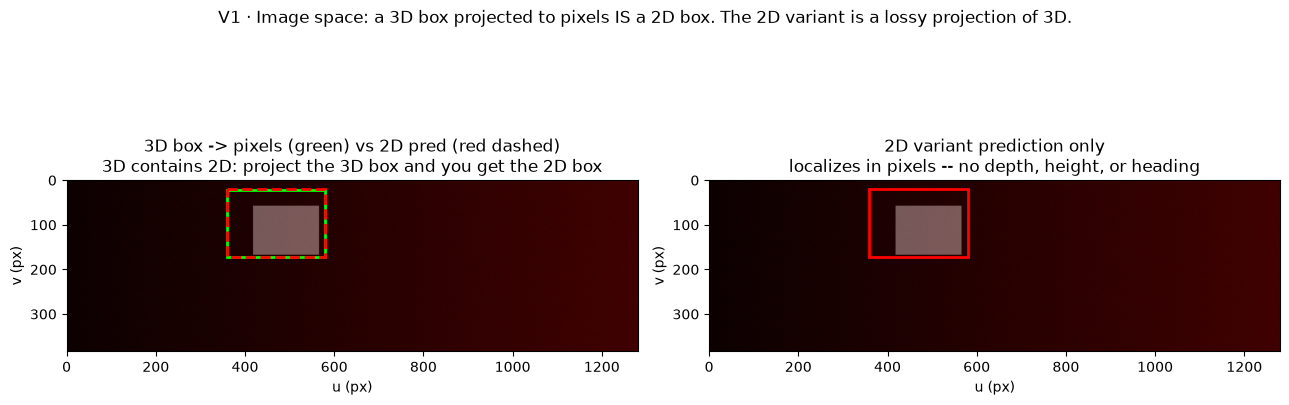

In [21]:
# ---- V1: image space -- 2D pixel box vs 3D box reprojected to pixels ----
gt_proj2d = box3d_to_2d_pixels(gt_box3d, calib, H, W)            # 3D box -> pixels (the "2D inside 3D")
pred2d = dec2d["boxes"][0].numpy() if dec2d["boxes"].shape[0] else gt_box2d
score2d = dec2d["scores"][0].item() if dec2d["boxes"].shape[0] else float("nan")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a in ax:
    a.imshow(img.clip(0,1), extent=[0, W, H, 0]); a.set_xlim(0, W); a.set_ylim(H, 0)
    a.set_xlabel("u (px)"); a.set_ylabel("v (px)")
def _rect(a, b, c, lw=2, ls="-"):
    x1, y1, x2, y2 = b; a.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor=c, lw=lw, linestyle=ls))
_rect(ax[0], gt_proj2d, "lime"); _rect(ax[0], pred2d, "red", ls="--")
ax[0].set_title("3D box -> pixels (green) vs 2D pred (red dashed)\n3D contains 2D: project the 3D box and you get the 2D box")
_rect(ax[1], pred2d, "red")
ax[1].set_title("2D variant prediction only\nlocalizes in pixels -- no depth, height, or heading")
plt.suptitle("V1 \u00b7 Image space: a 3D box projected to pixels IS a 2D box. The 2D variant is a lossy projection of 3D.")
plt.tight_layout(); plt.show()


### V2 · BEV space: 2D box = a bearing wedge; 3D box = an exact spot

This is the key picture. A 2D pixel box fixes only a *direction* from the camera — everything
along that wedge of rays is consistent with it. A 3D box picks one exact rotated rectangle inside
that wedge. **Depth is the missing dimension in 2D.**

C:\Users\varun\AppData\Local\Temp\ipykernel_99288\3226888241.py:12: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Polygon([(x, z) for (x, z) in wedge], closed=True, fill=True,


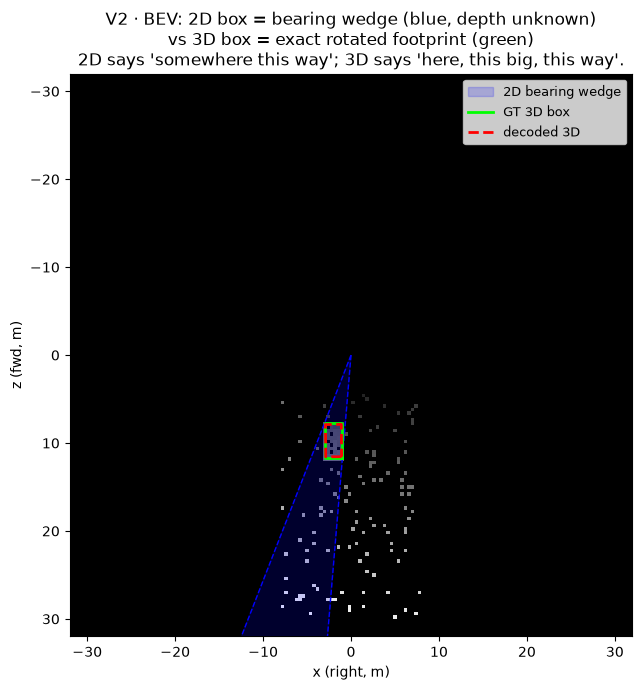

In [22]:
# ---- V2: BEV space -- 2D box = bearing wedge (no depth); 3D box = exact spot ----
fx_, cx_ = calib.P2[0, 0], calib.P2[0, 2]
def bearing_wedge(box2d, range_m, fx, cx):
    u1, u2 = box2d[0], box2d[2]
    x_left  = (u1 - cx) * range_m / fx
    x_right = (u2 - cx) * range_m / fx
    return [(0, 0), (x_right, range_m), (x_left, range_m)]   # (x, z) polygon
wedge = bearing_wedge(pred2d, RANGE, fx_, cx_)

fig, ax = plt.subplots(figsize=(7.5, 7))
ax.imshow(bev_lid[0].abs().sum(0).numpy(), cmap="gray", extent=[-RANGE, RANGE, RANGE, -RANGE])
ax.add_patch(patches.Polygon([(x, z) for (x, z) in wedge], closed=True, fill=True,
                             alpha=0.18, color="blue", edgecolor="blue", label="2D bearing wedge"))
ax.plot([0, wedge[1][0]], [0, wedge[1][1]], "b--", lw=1)
ax.plot([0, wedge[2][0]], [0, wedge[2][1]], "b--", lw=1)
gp = _bev_polygon(gt_box3d[0], gt_box3d[2], gt_box3d[3], gt_box3d[5], gt_box3d[6])
ax.plot([p[0] for p in gp]+[gp[0][0]], [p[1] for p in gp]+[gp[0][1]], "lime", lw=2, label="GT 3D box")
if dec["boxes"].shape[0]:
    db = dec["boxes"][0].numpy()
    dp = _bev_polygon(db[0], db[2], db[3], db[5], db[6])
    ax.plot([p[0] for p in dp]+[dp[0][0]], [p[1] for p in dp]+[dp[0][1]], "r--", lw=2, label="decoded 3D")
ax.set_xlim(-RANGE, RANGE); ax.set_ylim(RANGE, -RANGE); ax.set_xlabel("x (right, m)"); ax.set_ylabel("z (fwd, m)")
ax.legend(loc="upper right", fontsize=9)
ax.set_title("V2 \u00b7 BEV: 2D box = bearing wedge (blue, depth unknown)\nvs 3D box = exact rotated footprint (green)\n2D says 'somewhere this way'; 3D says 'here, this big, this way'.")
plt.tight_layout(); plt.show()


### V3 · Depth ambiguity: same bearing, different range

Two cars on the *same bearing* (same image column `u`) but at different ranges. In the image they
produce overlapping 2D boxes (2D conflates them). In BEV they are two clearly separated 3D boxes.
**Only 3D can tell them apart.**

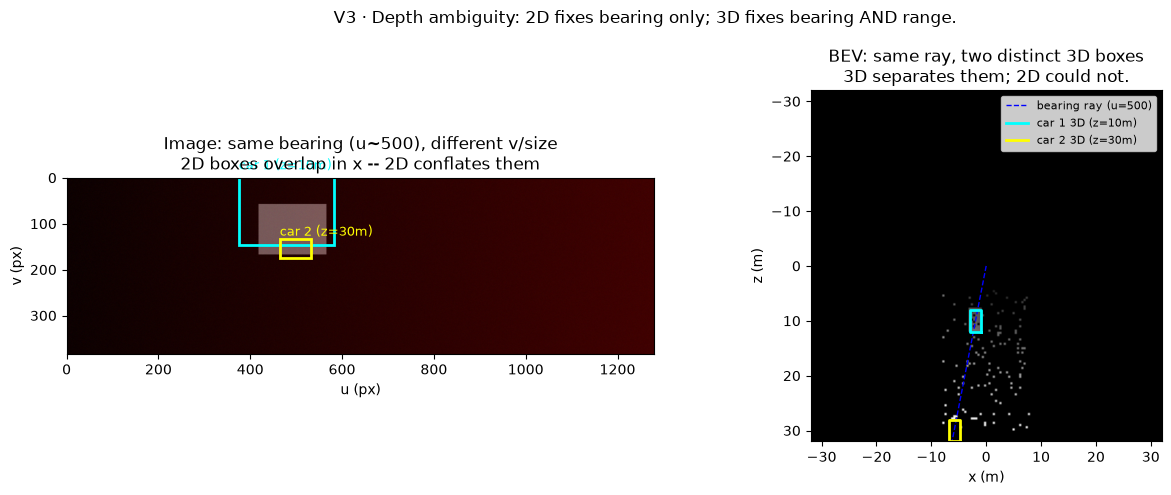

In [23]:
# ---- V3: depth ambiguity -- two cars, same bearing, different range ----
u0 = 500.0; ratio = (u0 - cx_) / fx_                       # fixed bearing (image column u=500)
cars = [(10.0, ratio*10.0), (30.0, ratio*30.0)]            # (z, x) cam frame, same bearing
boxes3d_amb = [np.array([xc, -1.5, zc, 2.0, 1.5, 4.0, 0.0]) for (zc, xc) in cars]
boxes2d_amb = np.array([box3d_to_2d_pixels(b, calib, H, W) for b in boxes3d_amb])

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].imshow(img.clip(0,1), extent=[0, W, H, 0]); ax[0].set_xlim(0, W); ax[0].set_ylim(H, 0)
for i, (b, col) in enumerate(zip(boxes2d_amb, ["cyan", "yellow"])):
    _rect(ax[0], b, col); ax[0].text(b[0], b[1]-8, f"car {i+1} (z={cars[i][0]:.0f}m)", color=col, fontsize=9)
ax[0].set_title("Image: same bearing (u~500), different v/size\n2D boxes overlap in x -- 2D conflates them")
ax[0].set_xlabel("u (px)"); ax[0].set_ylabel("v (px)")

ax[1].imshow(bev_lid[0].abs().sum(0).numpy(), cmap="gray", extent=[-RANGE, RANGE, RANGE, -RANGE])
ax[1].plot([0, ratio*RANGE], [0, RANGE], "b--", lw=1, label="bearing ray (u=500)")
for i, (b, col) in enumerate(zip(boxes3d_amb, ["cyan", "yellow"])):
    pp = _bev_polygon(b[0], b[2], b[3], b[5], b[6])
    ax[1].plot([p[0] for p in pp]+[pp[0][0]], [p[1] for p in pp]+[pp[0][1]], color=col, lw=2,
               label=f"car {i+1} 3D (z={b[2]:.0f}m)")
ax[1].set_xlim(-RANGE, RANGE); ax[1].set_ylim(RANGE, -RANGE); ax[1].set_xlabel("x (m)"); ax[1].set_ylabel("z (m)")
ax[1].legend(loc="upper right", fontsize=8)
ax[1].set_title("BEV: same ray, two distinct 3D boxes\n3D separates them; 2D could not.")
plt.suptitle("V3 \u00b7 Depth ambiguity: 2D fixes bearing only; 3D fixes bearing AND range.")
plt.tight_layout(); plt.show()


### V4 · Output representation: pixels vs the world

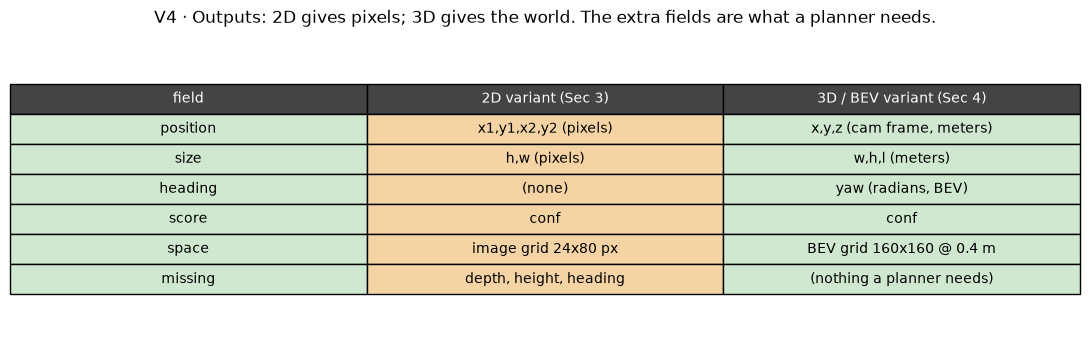

In [24]:
# ---- V4: output representation side by side ----
fig, ax = plt.subplots(figsize=(11, 3.4)); ax.axis("off")
rows = [
    ["position", "x1,y1,x2,y2 (pixels)", "x,y,z (cam frame, meters)"],
    ["size",     "h,w (pixels)",          "w,h,l (meters)"],
    ["heading",  "(none)",                "yaw (radians, BEV)"],
    ["score",    "conf",                  "conf"],
    ["space",    "image grid 24x80 px",   "BEV grid 160x160 @ 0.4 m"],
    ["missing",  "depth, height, heading", "(nothing a planner needs)"],
]
t = ax.table(cellText=rows, colLabels=["field", "2D variant (Sec 3)", "3D / BEV variant (Sec 4)"],
             cellLoc="center", loc="center")
t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1, 1.7)
for (r, c), cellz in t.get_celld().items():
    if r == 0:
        cellz.set_facecolor("#444"); cellz.get_text().set_color("white")
    elif c == 1:
        cellz.set_facecolor("#f4d4a4")
    else:
        cellz.set_facecolor("#cfe8cf")
plt.suptitle("V4 \u00b7 Outputs: 2D gives pixels; 3D gives the world. The extra fields are what a planner needs.")
plt.tight_layout(); plt.show()


### 2D vs 3D — the takeaway

- **3D contains 2D** (V1): project a 3D box to pixels and you get a 2D box. The reverse is not true.
- **2D is bearing-only** (V2): a pixel box is a *wedge* of rays; the 3D box is one spot inside it.
- **Depth is the missing dimension** (V3): cars along the same ray collapse to one 2D box but stay
  distinct in 3D.
- **Outputs** (V4): 2D → `(x1,y1,x2,y2,score)`; 3D → `(x,y,z,w,h,l,yaw,score)`. A planner needs the
  latter.

That is why the 3D/BEV variant is the heavy one to build: it is the only one that tells you *where in
the world, how big, and which way it points*.


## Recap

- **Camera → BEV:** image features `(32,24,80)` → per-pixel depth softmax over K bins → back-project
  every pixel×depth → splat into `BEV_cam (32,160,160)`. (simplified lift-splat-shoot)
- **LiDAR → BEV:** points → cam frame → BEV pillars → per-point MLP `(x,y,z,i,dx,dz)` → max-pool per
  cell → `BEV_lid (32,160,160)`. (simplified PointPillars)
- **Fuse:** `cat([BEV_cam, BEV_lid]) + 1x1` → `BEV_fused (64,160,160)` → `CenterHead3D` →
  `heat/off/height/size/yaw`.
- **Box:** `(x,y,z,w,h,l,yaw)`, decoded from the heatmap peak + regressed fields, `yaw = atan2(sin,cos)`.
- **Rotated IoU/NMS:** Sutherland–Hodgman polygon clip in `(x,z)` — rotation is essential.

Every shape above came from a real forward pass on a synthetic KITTI-style frame, mirroring
`fusion/fusion_3d/model.py`, `common/geometry/bev.py`, `boxes3d.py`, `common_3d.py`,
`lidar_encoder.py`, `heads.py`, `losses_3d.py`.

That completes Sections 0–4. If you want, the natural next notebook is **5 — training loop,
robustness sweeps (cam_blind / lidar_blind), and the cost/latency benchmark** across all four
variants, tying together `train/trainer.py`, `eval/robustness.py`, and `eval/benchmark.py`.
